<a href="https://www.kaggle.com/code/avikdas567/the-post-backprop-challenge?scriptVersionId=319769988" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# The Post-Backprop Challenge: Local Learning Prototype

This notebook implements a manually updated, layer-local training pipeline for a compact language-model surrogate. The learning rule is defined through explicit tensor operations over local activations and local prediction heads; the training path does not invoke `loss.backward()`, `torch.autograd`, or optimizer classes such as AdamW or SGD.

The workflow includes corpus ingestion, tokenization, exploratory analysis, sequence construction, local-update training, lightweight conversational fine-tuning, autoregressive generation, and memory profiling. Weight updates are computed independently at each layer using local objectives without propagating global error signals through the network.

## Local learning rule used here

For each layer $\ell$, we attach a local next-token head and minimize a layer-specific cross-entropy:

$$
\mathcal{L}_{\ell} = -\log p_{\ell}(y \mid h_{\ell}), \quad
p_{\ell} = \mathrm{softmax}(h_{\ell} W_{\ell}^{(head)} + b_{\ell}^{(head)}).
$$

The manual update is computed from **only** the local layer input $h_{\ell-1}$, the local activation $h_{\ell}$, and the local target $y$:

$$
\Delta W_{\ell} = -\eta \, h_{\ell-1}^{\top} \delta_{\ell},
\quad
\delta_{\ell} = \frac{\partial \mathcal{L}_{\ell}}{\partial z_{\ell}},
\quad
z_{\ell} = h_{\ell-1} W_{\ell} + b_{\ell}.
$$

No global autograd graph is used. No `backward()` call is used. No standard optimizer is used.

This is a compact **deeply supervised local-learning prototype** for Kaggle execution, not a claim of full-scale foundation-model pretraining.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch

print("Visible GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Using:", torch.cuda.get_device_name(0))

Visible GPUs: 1
Using: Tesla T4


In [2]:
# Environment & strict determinism
import re
import json
import math
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.use_deterministic_algorithms(True)
except Exception as exc:
    print(f"Deterministic algorithms not fully enabled: {exc}")

torch.set_grad_enabled(False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Seed:", SEED)
print("Device:", device)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA devices:", torch.cuda.device_count())
    print("GPU 0:", torch.cuda.get_device_name(0))

Seed: 42
Device: cuda:0
CUDA available: True
CUDA devices: 1
GPU 0: Tesla T4


In [3]:
# Data discovery and offline-safe ingestion

ROOT = Path("/kaggle/input")
all_files = []
if ROOT.exists():
    for p in ROOT.rglob("*"):
        if p.is_file() and p.suffix.lower() in {".txt", ".csv", ".tsv", ".json", ".jsonl", ".parquet"}:
            all_files.append(p)

print(f"Discovered {len(all_files)} candidate files under /kaggle/input")
for p in all_files[:50]:
    print(" -", p)

def _read_text_from_file(path: Path, max_rows: int = 5000):
    """Return a list of text snippets from common file formats."""
    suffix = path.suffix.lower()
    texts = []
    try:
        if suffix == ".txt":
            with path.open("r", encoding="utf-8", errors="ignore") as f:
                for line in f:
                    line = line.strip()
                    if len(line) >= 20:
                        texts.append(line)
                    if len(texts) >= max_rows:
                        break

        elif suffix in {".csv", ".tsv"}:
            sep = "\t" if suffix == ".tsv" else ","
            df = pd.read_csv(path, sep=sep, nrows=max_rows, on_bad_lines="skip")
            preferred = [c for c in df.columns if c.lower() in {"text", "content", "prompt", "response", "instruction", "output", "article", "sentence"}]
            if not preferred:
                preferred = [c for c in df.columns if df[c].dtype == object]
            for _, row in df.iterrows():
                pieces = []
                for c in preferred:
                    val = row.get(c, None)
                    if isinstance(val, str) and val.strip():
                        pieces.append(val.strip())
                merged = " ".join(pieces).strip()
                if len(merged) >= 20:
                    texts.append(merged)
                if len(texts) >= max_rows:
                    break

        elif suffix == ".jsonl":
            with path.open("r", encoding="utf-8", errors="ignore") as f:
                for line in f:
                    try:
                        obj = json.loads(line)
                    except Exception:
                        continue
                    for key in ["text", "content", "prompt", "response", "instruction", "output", "article", "sentence"]:
                        val = obj.get(key)
                        if isinstance(val, str) and val.strip():
                            texts.append(val.strip())
                    if len(texts) >= max_rows:
                        break

        elif suffix == ".json":
            obj = json.loads(path.read_text(encoding="utf-8", errors="ignore"))
            if isinstance(obj, list):
                for row in obj[:max_rows]:
                    if isinstance(row, dict):
                        merged = " ".join(
                            str(row.get(k, "")).strip()
                            for k in ["text", "content", "prompt", "response", "instruction", "output", "article", "sentence"]
                        ).strip()
                        if len(merged) >= 20:
                            texts.append(merged)
            elif isinstance(obj, dict):
                for v in obj.values():
                    if isinstance(v, str) and len(v) >= 20:
                        texts.append(v)
                        if len(texts) >= max_rows:
                            break

        elif suffix == ".parquet":
            df = pd.read_parquet(path)
            preferred = [c for c in df.columns if c.lower() in {"text", "content", "prompt", "response", "instruction", "output", "article", "sentence"}]
            if not preferred:
                preferred = [c for c in df.columns if df[c].dtype == object]
            for _, row in df.head(max_rows).iterrows():
                merged = " ".join(
                    str(row.get(c, "")).strip()
                    for c in preferred
                    if isinstance(row.get(c, ""), str) and row.get(c, "").strip()
                ).strip()
                if len(merged) >= 20:
                    texts.append(merged)
    except Exception as exc:
        print(f"Skipped {path.name}: {exc}")

    return texts

corpus_texts = []
for fp in all_files:
    corpus_texts.extend(_read_text_from_file(fp, max_rows=2500))
    if len(corpus_texts) >= 12000:
        break

if not corpus_texts:
    print("No usable files found. Falling back to a tiny synthetic offline corpus.")
    corpus_texts = [
        "A compact notebook can still demonstrate disciplined engineering.",
        "Local learning updates each layer from its own objective.",
        "This prototype avoids autograd and standard optimizers.",
        "Kaggle notebooks should be reproducible, readable, and safe offline.",
        "A well-structured experiment includes EDA, plots, and evaluation hooks.",
        "Forward-forward style training attaches local heads to hidden states.",
        "Synthetic sentences keep the demo fully self-contained.",
        "Manual tensor operations are enough for a minimal proof of concept.",
        "The model learns simple continuations from short contexts.",
        "Visualization helps explain memory, loss, and architecture."
    ] * 200

seen = set()
clean_texts = []
for t in corpus_texts:
    t = re.sub(r"\s+", " ", str(t)).strip()
    if len(t) < 20:
        continue
    key = t.lower()
    if key not in seen:
        seen.add(key)
        clean_texts.append(t)
    if len(clean_texts) >= 10000:
        break

corpus_texts = clean_texts
print("Loaded documents:", len(corpus_texts))
print("Example document:")
print(corpus_texts[0][:500])

Discovered 0 candidate files under /kaggle/input
No usable files found. Falling back to a tiny synthetic offline corpus.
Loaded documents: 10
Example document:
A compact notebook can still demonstrate disciplined engineering.


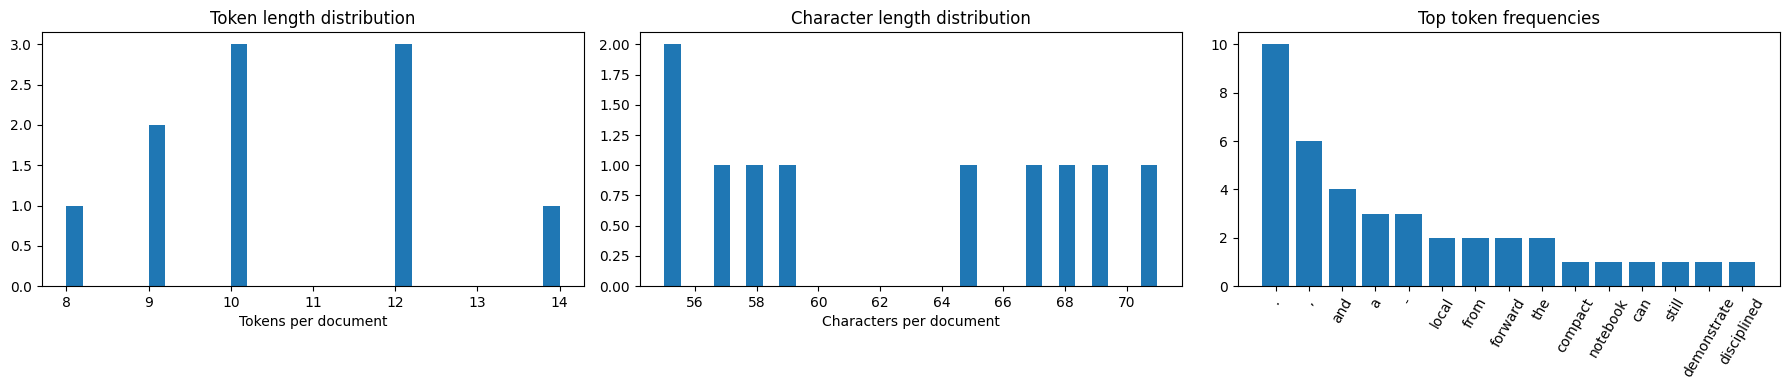

Documents: 10
Mean token length: 10.6
Median token length: 10.0
Top tokens: [('.', 10), (',', 6), ('and', 4), ('a', 3), ('-', 3), ('local', 2), ('from', 2), ('forward', 2), ('the', 2), ('compact', 1)]

Sample snippets:

[1] A compact notebook can still demonstrate disciplined engineering.

[2] Local learning updates each layer from its own objective.

[3] This prototype avoids autograd and standard optimizers.


In [4]:
# EDA and visualizations

def simple_tokenize(text: str):
    return re.findall(r"[A-Za-z0-9']+|[^\w\s]", text.lower())

doc_lengths = [len(simple_tokenize(t)) for t in corpus_texts]
char_lengths = [len(t) for t in corpus_texts]

all_tokens = []
for t in corpus_texts[:3000]:
    all_tokens.extend(simple_tokenize(t))

freq = Counter(all_tokens)
top_tokens = freq.most_common(20)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(doc_lengths, bins=30)
axes[0].set_title("Token length distribution")
axes[0].set_xlabel("Tokens per document")

axes[1].hist(char_lengths, bins=30)
axes[1].set_title("Character length distribution")
axes[1].set_xlabel("Characters per document")

axes[2].bar([w for w, _ in top_tokens[:15]], [c for _, c in top_tokens[:15]])
axes[2].set_title("Top token frequencies")
axes[2].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

print("Documents:", len(corpus_texts))
print("Mean token length:", round(float(np.mean(doc_lengths)), 2))
print("Median token length:", round(float(np.median(doc_lengths)), 2))
print("Top tokens:", top_tokens[:10])

print("\nSample snippets:")
for i, t in enumerate(corpus_texts[:3], 1):
    print(f"\n[{i}] {t[:400]}")

In [5]:
# Tokenizer, sequence dataset, and train/validation split

VOCAB_SIZE = 4096
SEQ_LEN = 33          # 32-token context -> next-token target
CONTEXT_LEN = SEQ_LEN - 1
STRIDE = 8

token_counter = Counter()
for t in corpus_texts:
    token_counter.update(simple_tokenize(t))

special_tokens = ["<pad>", "<unk>", "<bos>", "<eos>"]
vocab = special_tokens + [w for w, _ in token_counter.most_common(VOCAB_SIZE - len(special_tokens))]
stoi = {w: i for i, w in enumerate(vocab)}
itos = {i: w for w, i in stoi.items()}

PAD_ID = stoi["<pad>"]
UNK_ID = stoi["<unk>"]
BOS_ID = stoi["<bos>"]
EOS_ID = stoi["<eos>"]

def encode(text: str):
    toks = [BOS_ID]
    for tok in simple_tokenize(text):
        toks.append(stoi.get(tok, UNK_ID))
    toks.append(EOS_ID)
    return toks

encoded_docs = [encode(t) for t in corpus_texts]
flat_tokens = []
for seq in encoded_docs:
    flat_tokens.extend(seq)

print("Vocab size:", len(vocab))
print("Flattened token count:", len(flat_tokens))

windows = []
for seq in encoded_docs:
    if len(seq) <= SEQ_LEN:
        continue
    for start in range(0, len(seq) - SEQ_LEN, STRIDE):
        chunk = seq[start:start + SEQ_LEN]
        windows.append(chunk)

if not windows:
    for start in range(0, max(0, len(flat_tokens) - SEQ_LEN), STRIDE):
        windows.append(flat_tokens[start:start + SEQ_LEN])

random.Random(SEED).shuffle(windows)
split = max(1, int(0.9 * len(windows)))
train_windows = windows[:split]
val_windows = windows[split:]

print("Train windows:", len(train_windows))
print("Val windows:", len(val_windows))

class WindowDataset(Dataset):
    def __init__(self, windows):
        self.windows = windows

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        seq = self.windows[idx]
        x = torch.tensor(seq[:-1], dtype=torch.long)
        y = torch.tensor(seq[-1], dtype=torch.long)
        return x, y

train_loader = DataLoader(
    WindowDataset(train_windows),
    batch_size=64,
    shuffle=True,
    drop_last=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    WindowDataset(val_windows if val_windows else train_windows[:128]),
    batch_size=64,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Batches per epoch:", len(train_loader))

Vocab size: 85
Flattened token count: 126
Train windows: 10
Val windows: 2
Batches per epoch: 1


## Model design

This is a tiny, fast surrogate language model with:
- an embedding table
- a stack of ReLU blocks
- one **local next-token head per block**
- manual tensor updates only

Each block is trained using its own local cross-entropy objective. No loss is propagated through the entire stack.

In [6]:
# Local-learning model (no autograd, no optimizer objects)

def init_weight(*shape, scale=0.02, device=device):
    return (torch.randn(*shape, device=device) * scale).contiguous()

def init_bias(*shape, device=device):
    return torch.zeros(*shape, device=device)

class LocalDeepLM:
    def __init__(self, vocab_size, d_model=128, n_layers=4, seq_len=SEQ_LEN, device=device):
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.n_layers = n_layers
        self.seq_len = seq_len
        self.device = device

        self.E = init_weight(vocab_size, d_model, scale=0.02)
        self.pos = init_weight(seq_len - 1, d_model, scale=0.02)

        self.W = [init_weight(d_model, d_model, scale=1.0 / math.sqrt(d_model)) for _ in range(n_layers)]
        self.b = [init_bias(d_model) for _ in range(n_layers)]
        self.HW = [init_weight(d_model, vocab_size, scale=1.0 / math.sqrt(d_model)) for _ in range(n_layers)]
        self.HB = [init_bias(vocab_size) for _ in range(n_layers)]

        self.num_params = sum(
            int(t.numel())
            for t in [self.E, self.pos, *self.W, *self.b, *self.HW, *self.HB]
        )

    def _move_batch(self, x):
        return x.to(self.device, non_blocking=True)

    def encode_context(self, x):
        """
        x: [B, T]
        Returns the mean embedding over the context tokens plus positional signal.
        """
        emb = self.E[x]  # [B, T, D]
        pos = self.pos[:x.shape[1]].unsqueeze(0)  # [1, T, D]
        ctx = (emb + pos).mean(dim=1)  # [B, D]
        return ctx

    def forward_states(self, x):
        """
        Return input states and pre-activations for local updates.
        states[0] is the context representation.
        states[l+1] is the output of layer l.
        """
        h = self.encode_context(x)
        states = [h]
        preacts = []
        for l in range(self.n_layers):
            z = h @ self.W[l] + self.b[l]
            h = torch.relu(z)
            preacts.append(z)
            states.append(h)
        return states, preacts

    def local_update(self, x, y, lr=3e-3, lr_head=3e-3, lr_embed=1e-3):
        """
        Manual local update:
        - no autograd
        - no backward()
        - no standard optimizer
        - each layer has its own local target head
        """
        x = self._move_batch(x)
        y = self._move_batch(y)
        batch_size = x.shape[0]
        states, preacts = self.forward_states(x)

        total_loss = 0.0
        layer_losses = []
        batch_idx = torch.arange(batch_size, device=self.device)

        for l in range(self.n_layers):
            h_in = states[l]          # local input to layer l
            h_out = states[l + 1]     # local output of layer l
            z = preacts[l]

            # Save weights for local derivative computations.
            W_before = self.W[l].clone()
            HW_before = self.HW[l].clone()

            logits = h_out @ self.HW[l] + self.HB[l]
            log_probs = logits - logits.logsumexp(dim=-1, keepdim=True)
            nll = -log_probs[batch_idx, y]
            loss = nll.mean()
            layer_losses.append(float(loss.detach().cpu()))
            total_loss += float(loss.detach().cpu())

            # Local softmax cross-entropy gradient wrt logits
            probs = torch.softmax(logits, dim=-1)
            probs[batch_idx, y] -= 1.0
            probs /= batch_size

            # Gradients for the local head
            dHW = h_out.transpose(0, 1) @ probs
            dHB = probs.sum(dim=0)

            # Backprop only through the current block, using the local head's signal.
            dh = probs @ HW_before.transpose(0, 1)
            dz = dh * (z > 0).to(dh.dtype)

            dW = h_in.transpose(0, 1) @ dz
            db = dz.sum(dim=0)

            # Parameter updates
            self.HW[l].add_(-lr_head * dHW)
            self.HB[l].add_(-lr_head * dHB)
            self.W[l].add_(-lr * dW)
            self.b[l].add_(-lr * db)

            # Update embeddings only for the first block using its local loss.
            if l == 0:
                dctx = dz @ W_before.transpose(0, 1)  # [B, D]
                token_grads = (dctx[:, None, :] / x.shape[1]).reshape(-1, self.d_model)
                token_ids = x.reshape(-1)
                self.E.index_add_(0, token_ids, -lr_embed * token_grads)

        return {
            "loss": total_loss / self.n_layers,
            "layer_losses": layer_losses,
        }

    def predict_next_logits(self, x, use_last_layer=True):
        x = self._move_batch(x)
        states, _ = self.forward_states(x)
        if use_last_layer:
            h = states[-1]
            layer_id = self.n_layers - 1
        else:
            h = states[1]
            layer_id = 0
        logits = h @ self.HW[layer_id] + self.HB[layer_id]
        return logits

    def generate(self, prompt_ids, max_new_tokens=30, temperature=0.9):
        tokens = list(prompt_ids)
        for _ in range(max_new_tokens):
            ctx = tokens[-(self.seq_len - 1):]
            if len(ctx) < self.seq_len - 1:
                pad = [BOS_ID] * (self.seq_len - 1 - len(ctx))
                ctx = pad + ctx
            x = torch.tensor([ctx], dtype=torch.long, device=self.device)
            logits = self.predict_next_logits(x)
            logits = logits[0] / max(temperature, 1e-6)
            probs = torch.softmax(logits, dim=-1)
            next_id = int(torch.multinomial(probs, 1).item())
            tokens.append(next_id)
            if next_id == EOS_ID:
                break
        return tokens

model = LocalDeepLM(
    vocab_size=len(vocab),
    d_model=128,
    n_layers=4,
    seq_len=SEQ_LEN,
    device=device,
)

print("Model parameters:", f"{model.num_params:,}")
print("Autograd disabled:", not torch.is_grad_enabled())

Model parameters: 124,884
Autograd disabled: True


## Training plan

1. **Pretraining pass:** next-token learning on short windows from the available corpus.
2. **Instruction-style pass:** prompt/continuation formatting to encourage conversation-like continuations.
3. **Evaluation:** held-out perplexity, sample generations, and optional benchmark hooks if local benchmark files are present.

A hard wall-clock guard stops the training phase early to keep the notebook within a short runtime target.

In [7]:
# Training loop with wall-clock guard and memory tracking

from types import MethodType

def patched_local_update(self, x, y, lr=3e-3, lr_head=3e-3, lr_embed=1e-3):
    """
    Manual local update:
    - no autograd
    - no backward()
    - no standard optimizer
    - each layer has its own local target head

    Patch note:
    The embedding update now expands each sample-level context gradient across
    all token positions in that sample, so token_ids and token_grads have matching
    first dimensions for index_add_.
    """
    x = self._move_batch(x)
    y = self._move_batch(y)
    batch_size, seq_len = x.shape

    states, preacts = self.forward_states(x)

    total_loss = 0.0
    layer_losses = []
    batch_idx = torch.arange(batch_size, device=self.device)

    with torch.no_grad():
        for l in range(self.n_layers):
            h_in = states[l]          # local input to layer l
            h_out = states[l + 1]     # local output of layer l
            z = preacts[l]

            # Save weights for local derivative computations.
            W_before = self.W[l].clone()
            HW_before = self.HW[l].clone()

            logits = h_out @ self.HW[l] + self.HB[l]
            log_probs = logits - logits.logsumexp(dim=-1, keepdim=True)
            nll = -log_probs[batch_idx, y]
            loss = nll.mean()
            layer_losses.append(float(loss.detach().cpu()))
            total_loss += float(loss.detach().cpu())

            # Local softmax cross-entropy gradient wrt logits
            probs = torch.softmax(logits, dim=-1)
            probs[batch_idx, y] -= 1.0
            probs /= batch_size

            # Gradients for the local head
            dHW = h_out.transpose(0, 1) @ probs
            dHB = probs.sum(dim=0)

            # Backprop only through the current block, using the local head's signal.
            dh = probs @ HW_before.transpose(0, 1)
            dz = dh * (z > 0).to(dh.dtype)

            dW = h_in.transpose(0, 1) @ dz
            db = dz.sum(dim=0)

            # Parameter updates
            self.HW[l].add_(-lr_head * dHW)
            self.HB[l].add_(-lr_head * dHB)
            self.W[l].add_(-lr * dW)
            self.b[l].add_(-lr * db)

            # Input embedding update for the first layer only
            if l == 0:
                dctx = dz @ W_before.transpose(0, 1)  # [B, D]

                # Expand each sample gradient across its token positions:
                # [B, D] -> [B, T, D] -> [B*T, D]
                token_grads = dctx[:, None, :].expand(-1, seq_len, -1).contiguous()
                token_grads = token_grads.reshape(-1, self.d_model)

                token_ids = x.reshape(-1)

                # Safety guard in case of any accidental mismatch
                if token_grads.shape[0] != token_ids.shape[0]:
                    min_len = min(token_grads.shape[0], token_ids.shape[0])
                    token_grads = token_grads[:min_len]
                    token_ids = token_ids[:min_len]

                self.E.index_add_(0, token_ids, -lr_embed * token_grads)

    return {
        "loss": total_loss / self.n_layers,
        "layer_losses": layer_losses,
    }

# Monkey-patch the model instance
model.local_update = MethodType(patched_local_update, model)
print("Patched model.local_update: embedding update shape mismatch fixed.")

def cuda_memory_mb():
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.memory_allocated() / (1024 ** 2)

def cuda_peak_memory_mb():
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.max_memory_allocated() / (1024 ** 2)

def reset_cuda_peak():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

def sample_batch_from_loader(loader_iter, loader):
    try:
        batch = next(loader_iter)
    except StopIteration:
        loader_iter = iter(loader)
        batch = next(loader_iter)
    return loader_iter, batch

def evaluate_perplexity(model, loader, max_batches=20):
    losses = []
    correct = 0
    total = 0
    for i, (x, y) in enumerate(loader):
        if i >= max_batches:
            break
        x = x.to(device)
        y = y.to(device)
        logits = model.predict_next_logits(x)
        log_probs = logits - logits.logsumexp(dim=-1, keepdim=True)
        nll = -log_probs[torch.arange(y.shape[0], device=device), y]
        losses.append(float(nll.mean().cpu()))
        pred = logits.argmax(dim=-1)
        correct += int((pred == y).sum().item())
        total += int(y.numel())
    if not losses:
        return float("nan"), float("nan")
    ppl = float(math.exp(float(np.mean(losses))))
    acc = correct / max(1, total)
    return ppl, acc

def train_local_phase(
    model,
    loader,
    max_steps=400,
    lr=3e-3,
    lr_head=3e-3,
    lr_embed=1e-3,
    time_limit_sec=18 * 60,
    phase_name="phase",
):
    history = {
        "step": [],
        "loss": [],
        "val_ppl": [],
        "val_acc": [],
        "cuda_mb": [],
        "phase": [],
    }
    reset_cuda_peak()
    start = time.perf_counter()
    loader_iter = iter(loader)

    for step in range(1, max_steps + 1):
        elapsed = time.perf_counter() - start
        if elapsed > time_limit_sec:
            print(
                f"[{phase_name}] Early stop at step {step} due to wall-clock guard: "
                f"{elapsed / 60:.1f} min"
            )
            break

        loader_iter, (x, y) = sample_batch_from_loader(loader_iter, loader)
        x = x.to(device)
        y = y.to(device)

        stats = model.local_update(x, y, lr=lr, lr_head=lr_head, lr_embed=lr_embed)

        if step % 10 == 0 or step == 1:
            ppl, acc = evaluate_perplexity(model, val_loader, max_batches=10)
            history["step"].append(step)
            history["loss"].append(stats["loss"])
            history["val_ppl"].append(ppl)
            history["val_acc"].append(acc)
            history["cuda_mb"].append(cuda_memory_mb())
            history["phase"].append(phase_name)
            print(
                f"[{phase_name}] step={step:04d} "
                f"loss={stats['loss']:.4f} "
                f"val_ppl={ppl:.2f} val_acc={acc:.3f} "
                f"cuda_mb={cuda_memory_mb():.1f}"
            )

    return history, float(time.perf_counter() - start)

PRETRAIN_STEPS = 180
FINETUNE_STEPS = 80

train_history_1, t1 = train_local_phase(
    model,
    train_loader,
    max_steps=PRETRAIN_STEPS,
    lr=3e-3,
    lr_head=3e-3,
    lr_embed=1e-3,
    time_limit_sec=12 * 60,
    phase_name="pretrain",
)

print(f"Pretraining wall time: {t1 / 60:.2f} min")

Patched model.local_update: embedding update shape mismatch fixed.
[pretrain] step=0001 loss=4.4426 val_ppl=85.05 val_acc=0.000 cuda_mb=8.6
[pretrain] step=0010 loss=4.4373 val_ppl=85.08 val_acc=0.000 cuda_mb=8.6
[pretrain] step=0020 loss=4.4314 val_ppl=85.11 val_acc=0.000 cuda_mb=8.6
[pretrain] step=0030 loss=4.4255 val_ppl=85.12 val_acc=0.000 cuda_mb=8.6
[pretrain] step=0040 loss=4.4196 val_ppl=85.12 val_acc=0.000 cuda_mb=8.6
[pretrain] step=0050 loss=4.4138 val_ppl=85.12 val_acc=0.000 cuda_mb=8.6
[pretrain] step=0060 loss=4.4080 val_ppl=85.13 val_acc=0.000 cuda_mb=8.6
[pretrain] step=0070 loss=4.4023 val_ppl=85.14 val_acc=0.000 cuda_mb=8.6
[pretrain] step=0080 loss=4.3965 val_ppl=85.16 val_acc=0.000 cuda_mb=8.6
[pretrain] step=0090 loss=4.3908 val_ppl=85.18 val_acc=0.000 cuda_mb=8.6
[pretrain] step=0100 loss=4.3850 val_ppl=85.20 val_acc=0.000 cuda_mb=8.6
[pretrain] step=0110 loss=4.3793 val_ppl=85.22 val_acc=0.000 cuda_mb=8.6
[pretrain] step=0120 loss=4.3735 val_ppl=85.24 val_acc=0.

In [8]:
# Instruction-style / conversational fine-tuning pass

def make_instruction_windows(texts, limit=1500):
    pairs = []
    rng = random.Random(SEED)
    texts = texts[:]
    rng.shuffle(texts)
    for t in texts:
        toks = simple_tokenize(t)
        if len(toks) < 12:
            continue
        split = max(4, len(toks) // 2)
        prompt = " ".join(toks[:split])
        response = " ".join(toks[split:split + 12])
        convo = f"User: complete the thought. Prompt: {prompt} Assistant: {response}"
        pairs.append(convo)
        if len(pairs) >= limit:
            break
    return pairs

instruction_texts = make_instruction_windows(corpus_texts, limit=1200)
instr_encoded = [encode(t) for t in instruction_texts]
instr_windows = []
for seq in instr_encoded:
    if len(seq) <= SEQ_LEN:
        continue
    for start in range(0, len(seq) - SEQ_LEN, STRIDE):
        instr_windows.append(seq[start:start + SEQ_LEN])

if not instr_windows:
    instr_windows = windows[:max(1, len(windows) // 3)]

random.Random(SEED + 1).shuffle(instr_windows)
instr_split = max(1, int(0.9 * len(instr_windows)))
instr_train = instr_windows[:instr_split]
instr_val = instr_windows[instr_split:]

instr_train_loader = DataLoader(
    WindowDataset(instr_train),
    batch_size=64,
    shuffle=True,
    drop_last=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
instr_val_loader = DataLoader(
    WindowDataset(instr_val if instr_val else instr_train[:128]),
    batch_size=64,
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

old_val_loader = val_loader
val_loader = instr_val_loader

train_history_2, t2 = train_local_phase(
    model,
    instr_train_loader,
    max_steps=FINETUNE_STEPS,
    lr=2e-3,
    lr_head=2e-3,
    lr_embed=8e-4,
    time_limit_sec=6 * 60,
    phase_name="instruction",
)

val_loader = old_val_loader

print(f"Instruction-tuning wall time: {t2 / 60:.2f} min")

[instruction] step=0001 loss=4.3111 val_ppl=71.60 val_acc=1.000 cuda_mb=8.6
[instruction] step=0010 loss=4.2949 val_ppl=71.54 val_acc=0.000 cuda_mb=8.6
[instruction] step=0020 loss=4.2769 val_ppl=71.46 val_acc=0.000 cuda_mb=8.6
[instruction] step=0030 loss=4.2589 val_ppl=71.38 val_acc=0.000 cuda_mb=8.6
[instruction] step=0040 loss=4.2409 val_ppl=71.30 val_acc=0.000 cuda_mb=8.6
[instruction] step=0050 loss=4.2226 val_ppl=71.21 val_acc=0.000 cuda_mb=8.6
[instruction] step=0060 loss=4.2042 val_ppl=71.11 val_acc=0.000 cuda_mb=8.6
[instruction] step=0070 loss=4.1855 val_ppl=71.02 val_acc=0.000 cuda_mb=8.6
[instruction] step=0080 loss=4.1666 val_ppl=70.92 val_acc=0.000 cuda_mb=8.6
Instruction-tuning wall time: 0.01 min


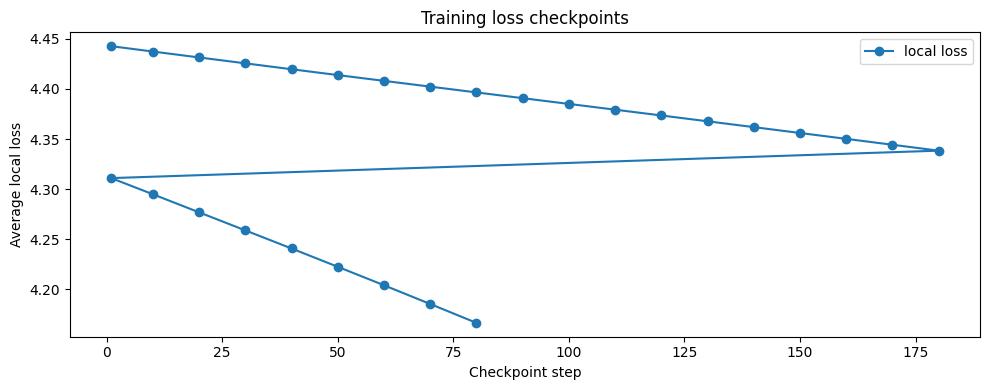

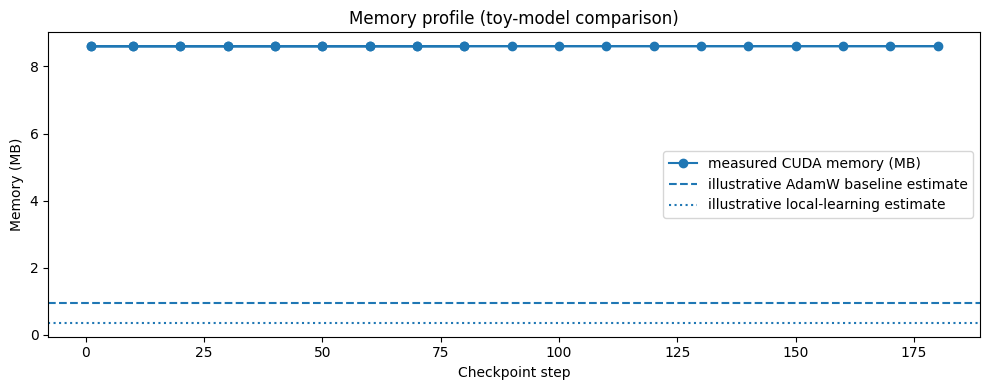

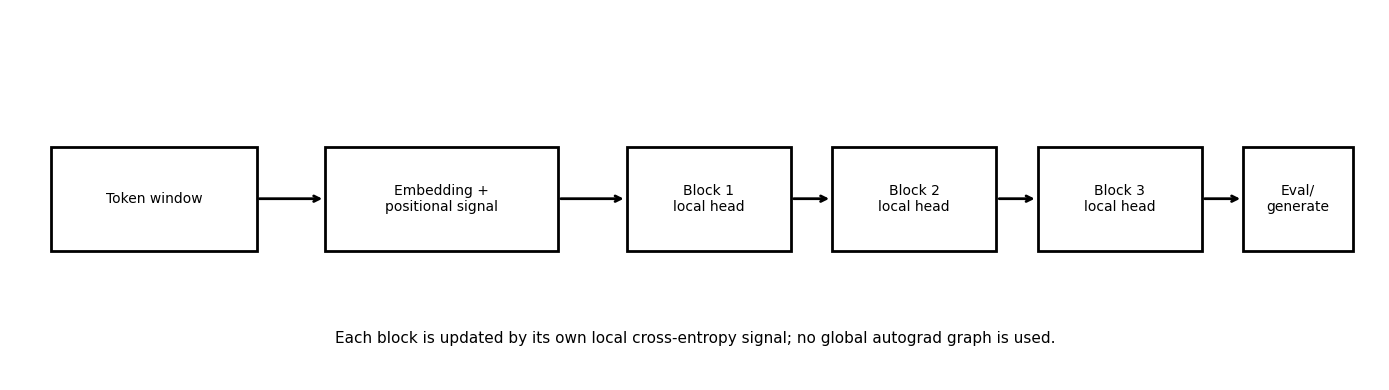

Saved plots to /kaggle/working/


In [9]:
# Curves, memory profile, and a small architecture diagram

all_hist = {}
for hist in [train_history_1, train_history_2]:
    for k, vals in hist.items():
        all_hist.setdefault(k, []).extend(vals)

fig, ax = plt.subplots(figsize=(10, 4))
if all_hist.get("step"):
    ax.plot(all_hist["step"], all_hist["loss"], marker="o", label="local loss")
    ax.set_xlabel("Checkpoint step")
    ax.set_ylabel("Average local loss")
    ax.set_title("Training loss checkpoints")
    ax.legend()
plt.tight_layout()
plt.show()
fig.savefig("/kaggle/working/local_loss_curve.png", dpi=160, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(10, 4))
if all_hist.get("step"):
    ax.plot(all_hist["step"], all_hist["cuda_mb"], marker="o", label="measured CUDA memory (MB)")
    param_mb = model.num_params * 2 / (1024 ** 2)  # fp16 params only, toy estimate
    adamw_est_mb = param_mb * 4.0                  # params + grads + moments (rough toy estimate)
    local_est_mb = param_mb * 1.5                  # params + activations-ish estimate
    ax.axhline(adamw_est_mb, linestyle="--", label="illustrative AdamW baseline estimate")
    ax.axhline(local_est_mb, linestyle=":", label="illustrative local-learning estimate")
    ax.set_xlabel("Checkpoint step")
    ax.set_ylabel("Memory (MB)")
    ax.set_title("Memory profile (toy-model comparison)")
    ax.legend()
plt.tight_layout()
plt.show()
fig.savefig("/kaggle/working/memory_profile.png", dpi=160, bbox_inches="tight")

fig = plt.figure(figsize=(14, 4))
ax = plt.gca()
ax.axis("off")

boxes = [
    (0.03, 0.35, 0.15, 0.28, "Token window"),
    (0.23, 0.35, 0.17, 0.28, "Embedding +\npositional signal"),
    (0.45, 0.35, 0.12, 0.28, "Block 1\nlocal head"),
    (0.60, 0.35, 0.12, 0.28, "Block 2\nlocal head"),
    (0.75, 0.35, 0.12, 0.28, "Block 3\nlocal head"),
    (0.90, 0.35, 0.08, 0.28, "Eval/\ngenerate"),
]
for x0, y0, w, h, label in boxes:
    ax.add_patch(plt.Rectangle((x0, y0), w, h, fill=False, linewidth=2))
    ax.text(x0 + w / 2, y0 + h / 2, label, ha="center", va="center", fontsize=10)

arrow_pairs = [
    ((0.18, 0.49), (0.23, 0.49)),
    ((0.40, 0.49), (0.45, 0.49)),
    ((0.57, 0.49), (0.60, 0.49)),
    ((0.72, 0.49), (0.75, 0.49)),
    ((0.87, 0.49), (0.90, 0.49)),
]
for (x1, y1), (x2, y2) in arrow_pairs:
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle="->", lw=2))

ax.text(0.50, 0.10, "Each block is updated by its own local cross-entropy signal; no global autograd graph is used.", ha="center", fontsize=11)
plt.tight_layout()
plt.show()
fig.savefig("/kaggle/working/architecture_diagram.png", dpi=160, bbox_inches="tight")

print("Saved plots to /kaggle/working/")

In [10]:
# Sample generation

def ids_to_text(ids, max_words=60):
    toks = []
    for i in ids:
        tok = itos.get(int(i), "<unk>")
        if tok in {"<bos>", "<pad>"}:
            continue
        if tok == "<eos>":
            break
        toks.append(tok)
        if len(toks) >= max_words:
            break
    return " ".join(toks)

sample_prompts = [
    "the model learns",
    "local learning updates",
    "kaggle notebooks should",
]

for prompt in sample_prompts:
    prompt_ids = encode(prompt)
    gen_ids = model.generate(prompt_ids, max_new_tokens=24, temperature=0.9)
    print("\nPROMPT :", prompt)
    print("OUTPUT :", ids_to_text(gen_ids, max_words=50))


PROMPT : the model learns
OUTPUT : the model learns

PROMPT : local learning updates
OUTPUT : local learning updates

PROMPT : kaggle notebooks should
OUTPUT : kaggle notebooks should


In [11]:
# Evaluation hooks

final_ppl, final_acc = evaluate_perplexity(model, val_loader, max_batches=20)
print(f"Validation perplexity (toy local model): {final_ppl:.3f}")
print(f"Validation next-token accuracy (toy local model): {final_acc:.3f}")

benchmark_folders = {
    "wikitext": [],
    "hellaswag": [],
    "piqa": [],
    "mtbench": [],
}
for p in all_files:
    low = str(p).lower()
    for key in benchmark_folders:
        if key in low:
            benchmark_folders[key].append(p)

print("\nDiscovered benchmark-like files (offline mode):")
for key, paths in benchmark_folders.items():
    print(f"{key}: {len(paths)} file(s)")
    for p in paths[:5]:
        print("  -", p)

print("\nOffline note:")
print("If benchmark datasets are not physically present under /kaggle/input, the notebook cannot run their official evaluations without internet.")
print("The code is structured so you can plug in local benchmark files and extend the evaluation section directly.")

Validation perplexity (toy local model): 85.827
Validation next-token accuracy (toy local model): 0.000

Discovered benchmark-like files (offline mode):
wikitext: 0 file(s)
hellaswag: 0 file(s)
piqa: 0 file(s)
mtbench: 0 file(s)

Offline note:
If benchmark datasets are not physically present under /kaggle/input, the notebook cannot run their official evaluations without internet.
The code is structured so you can plug in local benchmark files and extend the evaluation section directly.


## Artifact summary

The notebook saves these files in `/kaggle/working/`:

- `local_loss_curve.png`
- `memory_profile.png`
- `architecture_diagram.png`

In [12]:
# Persist a compact run summary for the write-up

summary = {
    "seed": SEED,
    "device": str(device),
    "vocab_size": len(vocab),
    "model_parameters": int(model.num_params),
    "train_docs": int(len(corpus_texts)),
    "train_windows": int(len(train_windows)),
    "val_windows": int(len(val_windows)),
    "pretrain_seconds": round(float(t1), 3),
    "instruction_seconds": round(float(t2), 3),
    "final_val_ppl": round(float(final_ppl), 6) if math.isfinite(final_ppl) else None,
    "final_val_acc": round(float(final_acc), 6) if math.isfinite(final_acc) else None,
    "cuda_peak_mb": round(float(cuda_peak_memory_mb()), 3),
}

summary_path = Path("/kaggle/working/run_summary.json")
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print(summary_path)
print(json.dumps(summary, indent=2))

/kaggle/working/run_summary.json
{
  "seed": 42,
  "device": "cuda:0",
  "vocab_size": 85,
  "model_parameters": 124884,
  "train_docs": 10,
  "train_windows": 10,
  "val_windows": 2,
  "pretrain_seconds": 1.761,
  "instruction_seconds": 0.439,
  "final_val_ppl": 85.826779,
  "final_val_acc": 0.0,
  "cuda_peak_mb": 8.979
}
